In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from iertools.read import read_sql
from dateutil.parser import parse

In [2]:
f = "../osm/013_modificacion/run/eplusout.sql"
cb = read_sql(f,alias=True)
data_cb = cb.data
data_cb

variable_name,BANO:Zone Air Relative Humidity (%),BANO:Zone Air Temperature (C),Ti_BANO,CIRCULACION:Zone Air Relative Humidity (%),CIRCULACION:Zone Air Temperature (C),Ti_CIRCULACION,COMERCIO:Zone Air Relative Humidity (%),COMERCIO:Zone Air Temperature (C),Ti_COMERCIO,ESCALERA:Zone Air Relative Humidity (%),...,To,RECAMARAPA:Zone Air Relative Humidity (%),RECAMARAPA:Zone Air Temperature (C),Ti_RECAMARAPA,RECAMARAPB:Zone Air Relative Humidity (%),RECAMARAPB:Zone Air Temperature (C),Ti_RECAMARAPB,SALA:Zone Air Relative Humidity (%),SALA:Zone Air Temperature (C),Ti_SALA
date,,,,,,,,,,,,,,,,,,,,,
2006-01-01 00:10:00,NaN,NaN,15.875336,NaN,NaN,18.341211,NaN,NaN,20.391096,NaN,...,8.566667,NaN,NaN,15.028296,NaN,NaN,15.060757,NaN,NaN,17.498457
2006-01-01 00:20:00,NaN,NaN,15.834611,NaN,NaN,18.265357,NaN,NaN,20.303718,NaN,...,8.333333,NaN,NaN,14.926259,NaN,NaN,14.997618,NaN,NaN,17.392559
2006-01-01 00:30:00,NaN,NaN,15.792917,NaN,NaN,18.191310,NaN,NaN,20.215694,NaN,...,8.100000,NaN,NaN,14.822109,NaN,NaN,14.932578,NaN,NaN,17.286770
2006-01-01 00:40:00,NaN,NaN,15.749197,NaN,NaN,18.119315,NaN,NaN,20.125153,NaN,...,7.866667,NaN,NaN,14.720761,NaN,NaN,14.863191,NaN,NaN,17.179488
2006-01-01 00:50:00,NaN,NaN,15.702778,NaN,NaN,18.047369,NaN,NaN,20.034640,NaN,...,7.633333,NaN,NaN,14.621861,NaN,NaN,14.788735,NaN,NaN,17.071413
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2006-12-31 23:20:00,NaN,NaN,15.600781,NaN,NaN,17.975080,NaN,NaN,20.117233,NaN,...,10.366667,NaN,NaN,15.115093,NaN,NaN,14.895479,NaN,NaN,17.493418
2006-12-31 23:30:00,NaN,NaN,15.575942,NaN,NaN,17.924359,NaN,NaN,20.040253,NaN,...,10.300000,NaN,NaN,15.041948,NaN,NaN,14.855624,NaN,NaN,17.410702
2006-12-31 23:40:00,NaN,NaN,15.549530,NaN,NaN,17.872016,NaN,NaN,19.963115,NaN,...,10.233333,NaN,NaN,14.967537,NaN,NaN,14.814164,NaN,NaN,17.326870


(np.float64(13269.0), np.float64(13300.0))

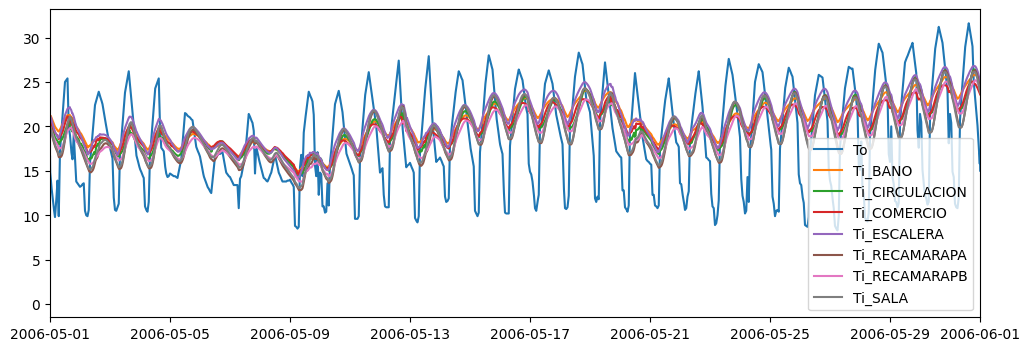

In [3]:
fig, ax = plt.subplots(figsize=(12,4))

f1 = parse("2006-05-01")
f2 = f1 + pd.Timedelta(days=31)

ax.plot(data_cb.To, label="To")
ax.plot(data_cb.Ti_BANO, label="Ti_BANO")
ax.plot(data_cb.Ti_CIRCULACION, label="Ti_CIRCULACION")
ax.plot(data_cb.Ti_COMERCIO, label="Ti_COMERCIO")
ax.plot(data_cb.Ti_ESCALERA, label="Ti_ESCALERA")
ax.plot(data_cb.Ti_RECAMARAPA, label="Ti_RECAMARAPA")
ax.plot(data_cb.Ti_RECAMARAPB, label="Ti_RECAMARAPB")
ax.plot(data_cb.Ti_SALA, label="Ti_SALA")

ax.legend()

ax.set_xlim(f1,f2)

In [4]:
a = {"bano":1.7*2.2}

In [5]:
areas = {"BANO":1.7*2.2, "CIRCULACION":3.7, "COMERCIO":3.4*3+1.2*0.7, "ESCALERA":2.2*2.7, "RECAMARAPA":2.6*4.4+1.7*2.2, "RECAMARAPB":2.6*4.4, "SALA":4.4*3.7}

In [6]:
pesos = {nombre: area / sum(areas.values()) for nombre, area in areas.items()}
pesos

{'BANO': 0.05555555555555555,
 'CIRCULACION': 0.054961378490790254,
 'COMERCIO': 0.1639928698752228,
 'ESCALERA': 0.08823529411764706,
 'RECAMARAPA': 0.22549019607843138,
 'RECAMARAPB': 0.16993464052287582,
 'SALA': 0.24183006535947713}

In [14]:
temps = data_cb.copy()
temps["Ti_CB"] = sum(temps[f"Ti_{zona}"] * peso for zona, peso in pesos.items())
temps

variable_name,BANO:Zone Air Relative Humidity (%),BANO:Zone Air Temperature (C),Ti_BANO,CIRCULACION:Zone Air Relative Humidity (%),CIRCULACION:Zone Air Temperature (C),Ti_CIRCULACION,COMERCIO:Zone Air Relative Humidity (%),COMERCIO:Zone Air Temperature (C),Ti_COMERCIO,ESCALERA:Zone Air Relative Humidity (%),...,RECAMARAPA:Zone Air Relative Humidity (%),RECAMARAPA:Zone Air Temperature (C),Ti_RECAMARAPA,RECAMARAPB:Zone Air Relative Humidity (%),RECAMARAPB:Zone Air Temperature (C),Ti_RECAMARAPB,SALA:Zone Air Relative Humidity (%),SALA:Zone Air Temperature (C),Ti_SALA,Ti_CB
date,,,,,,,,,,,,,,,,,,,,,
2006-01-01 00:10:00,NaN,NaN,15.875336,NaN,NaN,18.341211,NaN,NaN,20.391096,NaN,...,NaN,NaN,15.028296,NaN,NaN,15.060757,NaN,NaN,17.498457,16.866821
2006-01-01 00:20:00,NaN,NaN,15.834611,NaN,NaN,18.265357,NaN,NaN,20.303718,NaN,...,NaN,NaN,14.926259,NaN,NaN,14.997618,NaN,NaN,17.392559,16.781090
2006-01-01 00:30:00,NaN,NaN,15.792917,NaN,NaN,18.191310,NaN,NaN,20.215694,NaN,...,NaN,NaN,14.822109,NaN,NaN,14.932578,NaN,NaN,17.286770,16.694578
2006-01-01 00:40:00,NaN,NaN,15.749197,NaN,NaN,18.119315,NaN,NaN,20.125153,NaN,...,NaN,NaN,14.720761,NaN,NaN,14.863191,NaN,NaN,17.179488,16.607128
2006-01-01 00:50:00,NaN,NaN,15.702778,NaN,NaN,18.047369,NaN,NaN,20.034640,NaN,...,NaN,NaN,14.621861,NaN,NaN,14.788735,NaN,NaN,17.071413,16.518970
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2006-12-31 23:20:00,NaN,NaN,15.600781,NaN,NaN,17.975080,NaN,NaN,20.117233,NaN,...,NaN,NaN,15.115093,NaN,NaN,14.895479,NaN,NaN,17.493418,16.763921
2006-12-31 23:30:00,NaN,NaN,15.575942,NaN,NaN,17.924359,NaN,NaN,20.040253,NaN,...,NaN,NaN,15.041948,NaN,NaN,14.855624,NaN,NaN,17.410702,16.700208
2006-12-31 23:40:00,NaN,NaN,15.549530,NaN,NaN,17.872016,NaN,NaN,19.963115,NaN,...,NaN,NaN,14.967537,NaN,NaN,14.814164,NaN,NaN,17.326870,16.635332


(np.float64(13269.0), np.float64(13300.0))

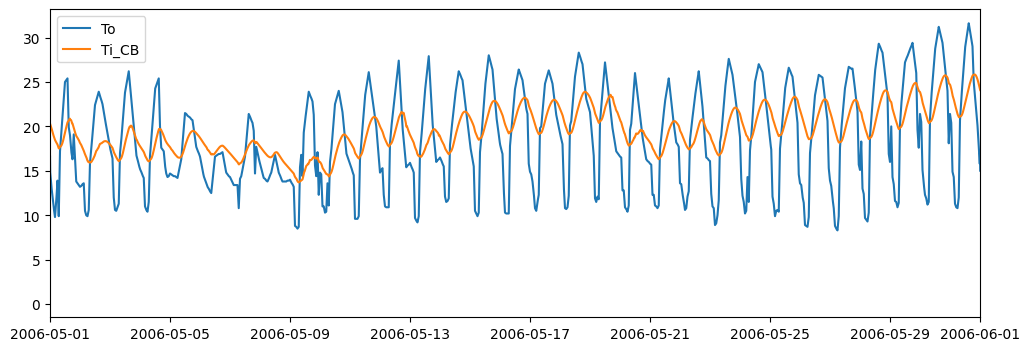

In [15]:
fig, ax = plt.subplots(figsize=(12,4))

f1 = parse("2006-05-01")
f2 = f1 + pd.Timedelta(days=31)

ax.plot(temps.To, label="To")
ax.plot(temps.Ti_CB, label="Ti_CB")

ax.legend()

ax.set_xlim(f1,f2)

In [16]:
f = "../osm/014_a0p25/run/eplusout.sql"
a0p25 = read_sql(f,alias=True)
data_a0p25 = a0p25.data
data_a0p25

variable_name,BANO:Zone Air Relative Humidity (%),BANO:Zone Air Temperature (C),Ti_BANO,CIRCULACION:Zone Air Relative Humidity (%),CIRCULACION:Zone Air Temperature (C),Ti_CIRCULACION,COMERCIO:Zone Air Relative Humidity (%),COMERCIO:Zone Air Temperature (C),Ti_COMERCIO,ESCALERA:Zone Air Relative Humidity (%),...,To,RECAMARAPA:Zone Air Relative Humidity (%),RECAMARAPA:Zone Air Temperature (C),Ti_RECAMARAPA,RECAMARAPB:Zone Air Relative Humidity (%),RECAMARAPB:Zone Air Temperature (C),Ti_RECAMARAPB,SALA:Zone Air Relative Humidity (%),SALA:Zone Air Temperature (C),Ti_SALA
date,,,,,,,,,,,,,,,,,,,,,
2006-01-01 00:10:00,NaN,NaN,14.069171,NaN,NaN,16.239915,NaN,NaN,18.302618,NaN,...,8.566667,NaN,NaN,12.789706,NaN,NaN,13.365523,NaN,NaN,14.955040
2006-01-01 00:20:00,NaN,NaN,14.035640,NaN,NaN,16.176996,NaN,NaN,18.223876,NaN,...,8.333333,NaN,NaN,12.708076,NaN,NaN,13.315890,NaN,NaN,14.869728
2006-01-01 00:30:00,NaN,NaN,14.001357,NaN,NaN,16.114859,NaN,NaN,18.143174,NaN,...,8.100000,NaN,NaN,12.628372,NaN,NaN,13.265924,NaN,NaN,14.783986
2006-01-01 00:40:00,NaN,NaN,13.965528,NaN,NaN,16.053658,NaN,NaN,18.059531,NaN,...,7.866667,NaN,NaN,12.549802,NaN,NaN,13.214051,NaN,NaN,14.696681
2006-01-01 00:50:00,NaN,NaN,13.928434,NaN,NaN,15.992295,NaN,NaN,17.975000,NaN,...,7.633333,NaN,NaN,12.471092,NaN,NaN,13.159910,NaN,NaN,14.608359
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2006-12-31 23:20:00,NaN,NaN,14.076039,NaN,NaN,16.135251,NaN,NaN,18.304886,NaN,...,10.366667,NaN,NaN,13.084120,NaN,NaN,13.411329,NaN,NaN,15.181749
2006-12-31 23:30:00,NaN,NaN,14.056672,NaN,NaN,16.096636,NaN,NaN,18.240979,NaN,...,10.300000,NaN,NaN,13.026970,NaN,NaN,13.382491,NaN,NaN,15.117876
2006-12-31 23:40:00,NaN,NaN,14.035761,NaN,NaN,16.056017,NaN,NaN,18.174897,NaN,...,10.233333,NaN,NaN,12.968337,NaN,NaN,13.352265,NaN,NaN,15.052672


In [17]:
temps["Ti_a0p25"] = sum(data_a0p25[f"Ti_{zona}"] * peso for zona, peso in pesos.items())
temps

variable_name,BANO:Zone Air Relative Humidity (%),BANO:Zone Air Temperature (C),Ti_BANO,CIRCULACION:Zone Air Relative Humidity (%),CIRCULACION:Zone Air Temperature (C),Ti_CIRCULACION,COMERCIO:Zone Air Relative Humidity (%),COMERCIO:Zone Air Temperature (C),Ti_COMERCIO,ESCALERA:Zone Air Relative Humidity (%),...,RECAMARAPA:Zone Air Temperature (C),Ti_RECAMARAPA,RECAMARAPB:Zone Air Relative Humidity (%),RECAMARAPB:Zone Air Temperature (C),Ti_RECAMARAPB,SALA:Zone Air Relative Humidity (%),SALA:Zone Air Temperature (C),Ti_SALA,Ti_CB,Ti_a0p25
date,,,,,,,,,,,,,,,,,,,,,
2006-01-01 00:10:00,NaN,NaN,15.875336,NaN,NaN,18.341211,NaN,NaN,20.391096,NaN,...,NaN,15.028296,NaN,NaN,15.060757,NaN,NaN,17.498457,16.866821,14.723733
2006-01-01 00:20:00,NaN,NaN,15.834611,NaN,NaN,18.265357,NaN,NaN,20.303718,NaN,...,NaN,14.926259,NaN,NaN,14.997618,NaN,NaN,17.392559,16.781090,14.653233
2006-01-01 00:30:00,NaN,NaN,15.792917,NaN,NaN,18.191310,NaN,NaN,20.215694,NaN,...,NaN,14.822109,NaN,NaN,14.932578,NaN,NaN,17.286770,16.694578,14.582641
2006-01-01 00:40:00,NaN,NaN,15.749197,NaN,NaN,18.119315,NaN,NaN,20.125153,NaN,...,NaN,14.720761,NaN,NaN,14.863191,NaN,NaN,17.179488,16.607128,14.510939
2006-01-01 00:50:00,NaN,NaN,15.702778,NaN,NaN,18.047369,NaN,NaN,20.034640,NaN,...,NaN,14.621861,NaN,NaN,14.788735,NaN,NaN,17.071413,16.518970,14.438225
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2006-12-31 23:20:00,NaN,NaN,15.600781,NaN,NaN,17.975080,NaN,NaN,20.117233,NaN,...,NaN,15.115093,NaN,NaN,14.895479,NaN,NaN,17.493418,16.763921,14.858670
2006-12-31 23:30:00,NaN,NaN,15.575942,NaN,NaN,17.924359,NaN,NaN,20.040253,NaN,...,NaN,15.041948,NaN,NaN,14.855624,NaN,NaN,17.410702,16.700208,14.808625
2006-12-31 23:40:00,NaN,NaN,15.549530,NaN,NaN,17.872016,NaN,NaN,19.963115,NaN,...,NaN,14.967537,NaN,NaN,14.814164,NaN,NaN,17.326870,16.635332,14.756996


(np.float64(13269.0), np.float64(13300.0))

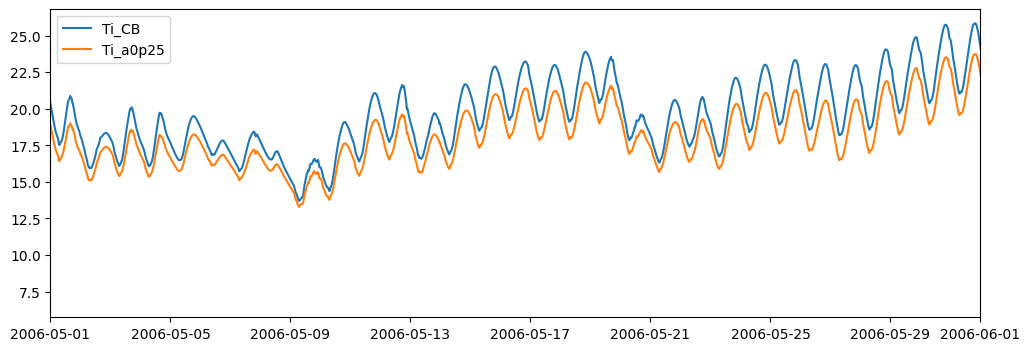

In [18]:
fig, ax = plt.subplots(figsize=(12,4))

f1 = parse("2006-05-01")
f2 = f1 + pd.Timedelta(days=31)

ax.plot(temps.Ti_CB, label="Ti_CB")
ax.plot(temps.Ti_a0p25, label="Ti_a0p25")

ax.legend()

ax.set_xlim(f1,f2)

In [19]:
f = "../osm/016_adobe/run/eplusout.sql"
adobe = read_sql(f,alias=True)
data_adobe = adobe.data
data_adobe

variable_name,BANO:Zone Air Relative Humidity (%),BANO:Zone Air Temperature (C),Ti_BANO,CIRCULACION:Zone Air Relative Humidity (%),CIRCULACION:Zone Air Temperature (C),Ti_CIRCULACION,COMERCIO:Zone Air Relative Humidity (%),COMERCIO:Zone Air Temperature (C),Ti_COMERCIO,ESCALERA:Zone Air Relative Humidity (%),...,To,RECAMARAPA:Zone Air Relative Humidity (%),RECAMARAPA:Zone Air Temperature (C),Ti_RECAMARAPA,RECAMARAPB:Zone Air Relative Humidity (%),RECAMARAPB:Zone Air Temperature (C),Ti_RECAMARAPB,SALA:Zone Air Relative Humidity (%),SALA:Zone Air Temperature (C),Ti_SALA
date,,,,,,,,,,,,,,,,,,,,,
2006-01-01 00:10:00,NaN,NaN,13.972583,NaN,NaN,16.108166,NaN,NaN,18.453436,NaN,...,8.566667,NaN,NaN,12.544660,NaN,NaN,13.139615,NaN,NaN,14.930799
2006-01-01 00:20:00,NaN,NaN,13.951578,NaN,NaN,16.066274,NaN,NaN,18.385855,NaN,...,8.333333,NaN,NaN,12.488172,NaN,NaN,13.112622,NaN,NaN,14.865982
2006-01-01 00:30:00,NaN,NaN,13.929858,NaN,NaN,16.024776,NaN,NaN,18.319531,NaN,...,8.100000,NaN,NaN,12.430244,NaN,NaN,13.085495,NaN,NaN,14.800537
2006-01-01 00:40:00,NaN,NaN,13.906761,NaN,NaN,15.983754,NaN,NaN,18.251408,NaN,...,7.866667,NaN,NaN,12.372337,NaN,NaN,13.056858,NaN,NaN,14.733350
2006-01-01 00:50:00,NaN,NaN,13.882703,NaN,NaN,15.942168,NaN,NaN,18.181614,NaN,...,7.633333,NaN,NaN,12.314894,NaN,NaN,13.026492,NaN,NaN,14.664998
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2006-12-31 23:20:00,NaN,NaN,13.889737,NaN,NaN,15.866801,NaN,NaN,18.310348,NaN,...,10.366667,NaN,NaN,12.878233,NaN,NaN,13.187481,NaN,NaN,15.112066
2006-12-31 23:30:00,NaN,NaN,13.879432,NaN,NaN,15.845366,NaN,NaN,18.258812,NaN,...,10.300000,NaN,NaN,12.838418,NaN,NaN,13.175525,NaN,NaN,15.063745
2006-12-31 23:40:00,NaN,NaN,13.867549,NaN,NaN,15.821536,NaN,NaN,18.205828,NaN,...,10.233333,NaN,NaN,12.797160,NaN,NaN,13.162381,NaN,NaN,15.013986


In [20]:
temps["Ti_adobe"] = sum(data_adobe[f"Ti_{zona}"] * peso for zona, peso in pesos.items())
temps

variable_name,BANO:Zone Air Relative Humidity (%),BANO:Zone Air Temperature (C),Ti_BANO,CIRCULACION:Zone Air Relative Humidity (%),CIRCULACION:Zone Air Temperature (C),Ti_CIRCULACION,COMERCIO:Zone Air Relative Humidity (%),COMERCIO:Zone Air Temperature (C),Ti_COMERCIO,ESCALERA:Zone Air Relative Humidity (%),...,Ti_RECAMARAPA,RECAMARAPB:Zone Air Relative Humidity (%),RECAMARAPB:Zone Air Temperature (C),Ti_RECAMARAPB,SALA:Zone Air Relative Humidity (%),SALA:Zone Air Temperature (C),Ti_SALA,Ti_CB,Ti_a0p25,Ti_adobe
date,,,,,,,,,,,,,,,,,,,,,
2006-01-01 00:10:00,NaN,NaN,15.875336,NaN,NaN,18.341211,NaN,NaN,20.391096,NaN,...,15.028296,NaN,NaN,15.060757,NaN,NaN,17.498457,16.866821,14.723733,14.626421
2006-01-01 00:20:00,NaN,NaN,15.834611,NaN,NaN,18.265357,NaN,NaN,20.303718,NaN,...,14.926259,NaN,NaN,14.997618,NaN,NaN,17.392559,16.781090,14.653233,14.575291
2006-01-01 00:30:00,NaN,NaN,15.792917,NaN,NaN,18.191310,NaN,NaN,20.215694,NaN,...,14.822109,NaN,NaN,14.932578,NaN,NaN,17.286770,16.694578,14.582641,14.523813
2006-01-01 00:40:00,NaN,NaN,15.749197,NaN,NaN,18.119315,NaN,NaN,20.125153,NaN,...,14.720761,NaN,NaN,14.863191,NaN,NaN,17.179488,16.607128,14.510939,14.471190
2006-01-01 00:50:00,NaN,NaN,15.702778,NaN,NaN,18.047369,NaN,NaN,20.034640,NaN,...,14.621861,NaN,NaN,14.788735,NaN,NaN,17.071413,16.518970,14.438225,14.417641
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2006-12-31 23:20:00,NaN,NaN,15.600781,NaN,NaN,17.975080,NaN,NaN,20.117233,NaN,...,15.115093,NaN,NaN,14.895479,NaN,NaN,17.493418,16.763921,14.858670,14.718538
2006-12-31 23:30:00,NaN,NaN,15.575942,NaN,NaN,17.924359,NaN,NaN,20.040253,NaN,...,15.041948,NaN,NaN,14.855624,NaN,NaN,17.410702,16.700208,14.808625,14.683317
2006-12-31 23:40:00,NaN,NaN,15.549530,NaN,NaN,17.872016,NaN,NaN,19.963115,NaN,...,14.967537,NaN,NaN,14.814164,NaN,NaN,17.326870,16.635332,14.756996,14.646629


(np.float64(13269.0), np.float64(13300.0))

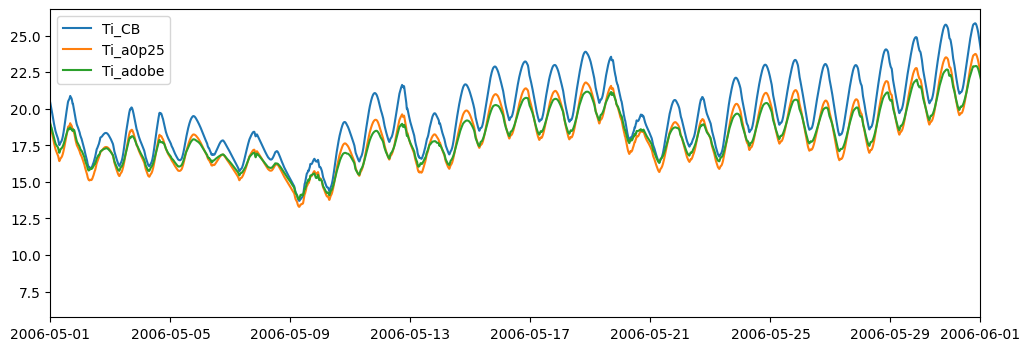

In [21]:
fig, ax = plt.subplots(figsize=(12,4))

f1 = parse("2006-05-01")
f2 = f1 + pd.Timedelta(days=31)

ax.plot(temps.Ti_CB, label="Ti_CB")
ax.plot(temps.Ti_a0p25, label="Ti_a0p25")
ax.plot(temps.Ti_adobe, label="Ti_adobe")

ax.legend()

ax.set_xlim(f1,f2)